In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pandas as pd 
data = load_iris()
iris_data = pd.DataFrame(data.data, columns=data.feature_names)
X = data.data 
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state = 99)
clf = DecisionTreeClassifier(random_state=1)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')
iris_data.head()

Accuracy: 0.9555555555555556


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
data = load_iris()
X = data.data 
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state = 99)
# Hyperparameter tuning using GridSearchCV ____________________________________
from sklearn.model_selection import GridSearchCV
param_grid = {
   'max_depth': range(1, 10, 1), # [1,2,3,4,5,6,7,8,9] => 10 values
   'min_samples_leaf': range(1, 20, 2), # [1,3,5,7,9,11,13,15,17,19] => 10 values
   'min_samples_split': range(2, 20, 2), # [2,4,6,8,10,12,14,16,18] => 9 values
   'criterion': ["entropy", "gini"] # ["entropy", "gini"] => 2 values
}
# _____________________________________________________________________________
tree = DecisionTreeClassifier(random_state=1)
grid_search = GridSearchCV(estimator=tree, param_grid=param_grid, cv=5, verbose=True)
grid_search.fit(X_train, y_train)
print("best accuracy", grid_search.best_score_)
print(grid_search.best_estimator_)

Fitting 5 folds for each of 180 candidates, totalling 900 fits
best accuracy 0.9714285714285715
DecisionTreeClassifier(criterion='entropy', max_depth=4, min_samples_leaf=3,
                       random_state=1)


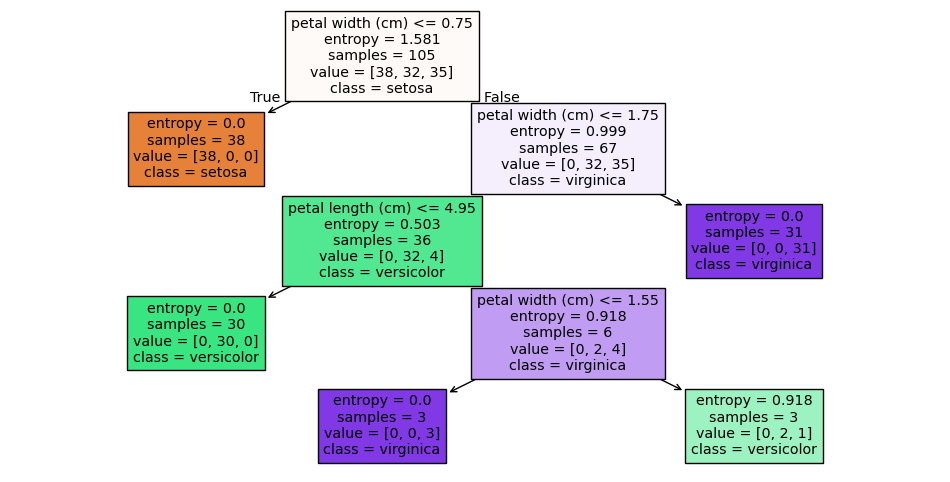

In [4]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
tree_clf = grid_search.best_estimator_
plt.figure(figsize=(12, 6))
plot_tree(tree_clf, filled=True, feature_names=data.feature_names, class_names=data.target_names)
plt.show()